# Multimodal RAG System for Autonomous Driving

**Author:** Victor  
**Project:** Multimodal Retrieval-Augmented Generation

---

## Overview

This notebook demonstrates a production-ready **multimodal Retrieval-Augmented Generation (RAG)** system designed for autonomous driving datasets. The system combines:

1. **CLIP (ViT-g-14)** - For robust image and text embeddings in a unified vector space
2. **Qwen2-VL-7B** - For intelligent scene captioning and natural language generation
3. **Qdrant Vector Database** - For efficient similarity search across millions of images

### Key Capabilities

- **Multimodal Search**: Query driving scenes using natural language ("yellow taxi", "pedestrians crossing street")
- **Scene Understanding**: Automatically generate detailed descriptions of driving scenarios
- **Intelligent Q&A**: Answer questions about specific traffic situations using retrieved visual context

### Architecture Decisions

| Component | Choice | Rationale |
|-----------|--------|----------|
| Image Embeddings | CLIP ViT-g-14 | 1024-dim unified image-text space, SOTA zero-shot performance |
| Text Embeddings | Nomic-embed-text-v1.5 | 768-dim, optimized for semantic search |
| VLM Captioner | Qwen2-VL-7B | Efficient 7B model with strong vision-language understanding |
| Vector Store | Qdrant | In-memory mode for prototyping, scalable to production |

---

## Section 1: Environment Setup

Configure GPU environment and suppress warnings for clean output.

In [1]:
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

import os
from dotenv import load_dotenv

# Load environment variables (API keys, etc.)
load_dotenv("11.env")

# Configure CUDA device
os.environ['CUDA_VISIBLE_DEVICES'] = "0"  # Use first GPU
os.environ['HF_HOME'] = 'hf_home'  # HuggingFace cache directory
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid tokenizer warnings

print(" Environment configured")
print(f"  GPU: {os.environ['CUDA_VISIBLE_DEVICES']}")

 Environment configured
  GPU: 0


## Section 2: Import Dependencies

Core libraries for multimodal processing and vector search.

In [2]:
import base64
import torch
from PIL import Image
from pathlib import Path
from typing import List, Dict, Any, Optional
from uuid import uuid4
from itertools import islice
from io import BytesIO

# Pydantic for robust model configuration
from pydantic import BaseModel, ConfigDict, model_validator

# Qdrant for vector similarity search
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, VectorParams

# Transformers for Qwen2-VL
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    GenerationConfig
)

# Sentence transformers for text embeddings
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

print(" All dependencies imported successfully")

 All dependencies imported successfully


---

## Section 3: Custom CLIP Embeddings Class

**Design Pattern:** This class wraps OpenCLIP to provide a unified interface for:
- Text embedding (queries like "red car")
- Image embedding (driving scene photos)

**Key Feature:** Both outputs live in the **same 1024-dimensional vector space**, enabling direct image-text similarity comparison.

**Technical Details:**
- Model: ViT-g-14 (Vision Transformer with 1B parameters)
- Pretraining: LAION-2B dataset (2 billion image-text pairs)
- Normalization: L2 normalization for cosine similarity

In [3]:
class CustomOpenCLIPEmbeddings(BaseModel):
    """
    CLIP-based embeddings for multimodal similarity search.
    
    This class provides a unified interface for encoding both images and text
    into a shared 1024-dimensional vector space, enabling cross-modal retrieval.
    
    Attributes:
        model: OpenCLIP vision-language model
        preprocess: Image preprocessing pipeline (resize, normalize, etc.)
        tokenizer: Text tokenizer for CLIP
        device: CUDA device for GPU acceleration
    """
    
    model: Any
    preprocess: Any
    tokenizer: Any
    device: str = "cuda:0"
    model_name: str = "ViT-g-14"
    checkpoint: str = "laion2b_s34b_b88k"
    
    model_config = ConfigDict(protected_namespaces=())

    @model_validator(mode="before")
    @classmethod
    def validate_environment(cls, values: Dict) -> Dict:
        """
        Initialize CLIP model during class instantiation.
        Uses Pydantic's validator pattern for robust initialization.
        """
        try:
            import open_clip
        except ImportError:
            raise ImportError(
                "Please install open_clip: pip install open_clip_torch"
            )
        
        model_name = values.get("model_name", "ViT-g-14")
        checkpoint = values.get("checkpoint", "laion2b_s34b_b88k")
        
        # Load pretrained CLIP model
        model, _, preprocess = open_clip.create_model_and_transforms(
            model_name=model_name, 
            pretrained=checkpoint
        )
        tokenizer = open_clip.get_tokenizer(model_name)
        
        values["model"] = model
        values["preprocess"] = preprocess
        values["tokenizer"] = tokenizer
        
        return values

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        """
        Encode multiple text strings into CLIP embeddings.
        
        Process:
        1. Tokenize text (convert to token IDs)
        2. Pass through CLIP text encoder
        3. L2 normalize (for cosine similarity)
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            List of 1024-dim normalized embeddings
        """
        text_features = []
        self.model.to(self.device)
        
        for text in texts:
            # Tokenize text input
            tokenized_text = self.tokenizer(text)
            
            with torch.no_grad():
                # Encode text through CLIP's text encoder
                embeddings_tensor = self.model.encode_text(
                    tokenized_text.to(self.device)
                )
            
            # L2 normalize: ||v|| = 1 (enables cosine similarity)
            norm = embeddings_tensor.norm(p=2, dim=1, keepdim=True)
            normalized_embeddings_tensor = embeddings_tensor.div(norm)
            embeddings_list = normalized_embeddings_tensor.squeeze(0).tolist()
            text_features.append(embeddings_list)
        
        return text_features

    def embed_query(self, text: str) -> List[float]:
        """
        Convenience method for single text embedding.
        Used for query encoding in similarity search.
        """
        return self.embed_documents([text])[0]
    
    def embed_image(self, uris: List[str]) -> List[List[float]]:
        """
        Encode multiple images into CLIP embeddings.
        
        Process:
        1. Load image from file path
        2. Preprocess (resize to 224x224, normalize)
        3. Pass through CLIP vision encoder
        4. L2 normalize
        
        Args:
            uris: List of image file paths
            
        Returns:
            List of 1024-dim normalized embeddings
        """
        try:
            from PIL import Image as _PILImage
        except ImportError:
            raise ImportError("Please install PIL: pip install pillow")
        
        self.model.to(self.device)
        image_features = []
        
        for uri in uris:
            # Load and preprocess image
            pil_image = _PILImage.open(uri)
            preprocessed_image = self.preprocess(pil_image).unsqueeze(0)
            
            with torch.no_grad():
                # Encode image through CLIP's vision encoder (ViT)
                embeddings_tensor = self.model.encode_image(
                    preprocessed_image.to(self.device)
                )
            
            # L2 normalize for cosine similarity
            norm = embeddings_tensor.norm(p=2, dim=1, keepdim=True)
            normalized_embeddings_tensor = embeddings_tensor.div(norm)
            embeddings_list = normalized_embeddings_tensor.squeeze(0).tolist()
            image_features.append(embeddings_list)
        
        return image_features

print(" CustomOpenCLIPEmbeddings class defined")

 CustomOpenCLIPEmbeddings class defined


---

## Section 4: Qwen2-VL Captioner Class

**Purpose:** This class handles two critical tasks:
1. **Scene Captioning** - Generate natural language descriptions of driving scenes
2. **RAG Generation** - Answer questions using retrieved context

**Design Pattern:** Separates embedding (CLIP) from generation (Qwen2-VL).

In [4]:
class Qwen2VLCaptioner(BaseModel):
    """
    Qwen2-VL for scene captioning and text generation.
    
    This class wraps Qwen2-VL-7B-Instruct for two tasks:
    1. Generating descriptions of driving scenes
    2. Answering questions using retrieval-augmented generation
    
    Attributes:
        model: Qwen2VLForConditionalGeneration model
        processor: AutoProcessor for image/text preprocessing
        device: CUDA device for GPU acceleration
    """
    
    model: Any
    processor: Any
    device: str = "cuda:0"
    model_name: str = "Qwen/Qwen2-VL-7B-Instruct"
    
    model_config = ConfigDict(
        protected_namespaces=(), 
        arbitrary_types_allowed=True
    )

    @model_validator(mode="before")
    @classmethod
    def validate_environment(cls, values: Dict) -> Dict:
        """
        Load Qwen2-VL model during initialization.
        Uses FP16 for memory efficiency.
        """
        model_name = values.get("model_name", "Qwen/Qwen2-VL-7B-Instruct")
        device = values.get("device", "cuda:0")
        
        print(f"Loading Qwen2-VL: {model_name} on {device}...")
        
        # Load model in FP16 for 2x memory savings
        model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,  # FP16 reduces VRAM from ~28GB to ~14GB
            device_map=device,
        )
        processor = AutoProcessor.from_pretrained(model_name)
        model.eval()  # Set to evaluation mode (disable dropout)
        
        values["model"] = model
        values["processor"] = processor
        
        print(f" Qwen2-VL loaded successfully")
        return values
    
    def caption_image(self, image_path: str) -> str:
        """
        Generate a natural language description of a driving scene.
        
        Process:
        1. Load image from path
        2. Create conversation with vision + text prompt
        3. Generate description using VLM
        4. Extract and return clean caption
        
        Args:
            image_path: Path to driving scene image
            
        Returns:
            Natural language scene description
            
        Example Output:
            "A yellow taxi drives through an intersection with pedestrians 
            crossing in a crosswalk, traffic lights showing green."
        """
        image = Image.open(image_path).convert('RGB')
        
        # Construct conversation in Qwen2-VL's expected format
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},  # Visual input
                    {
                        "type": "text", 
                        "text": "Describe this driving scene in one sentence. What vehicles and objects do you see?"
                    }
                ],
            },
        ]
        
        # Apply chat template (adds special tokens like <|im_start|>)
        prompt = self.processor.apply_chat_template(
            conversation, 
            add_generation_prompt=True
        )
        
        # Configure generation (greedy decoding for consistency)
        generation_config = GenerationConfig(**{
            'max_new_tokens': 128,  # Limit response length
            'do_sample': False,  # Greedy decoding (deterministic)
        })
        
        # Preprocess image + text
        inputs = self.processor(
            images=[image], 
            text=[prompt], 
            padding=True,
            return_tensors="pt"
        ).to(self.device)
        
        # Generate caption
        generated_ids = self.model.generate(
            **inputs, 
            generation_config=generation_config
        )
        
        # Trim input tokens (only keep generated text)
        generated_ids_trimmed = [
            out_ids[len(in_ids):] 
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        
        # Decode tokens to text
        response = self.processor.batch_decode(
            generated_ids_trimmed, 
            skip_special_tokens=True, 
            clean_up_tokenization_spaces=False
        )[0]
        
        # Extract clean caption (remove role prefix)
        caption = response.split("assistant")[-1].strip()
        return caption
    
    def generate_text(self, prompt: str) -> str:
        """
        Generate text response for RAG chatbot.
        
        Used in the RAG pipeline to answer questions about retrieved images.
        The prompt should include both the retrieved scene description and
        the user's question.
        
        Args:
            prompt: Formatted RAG prompt with context + question
            
        Returns:
            Generated answer
            
        Example:
            Input: "Scene: Yellow taxi at intersection. Question: What color is the taxi?"
            Output: "The taxi is yellow."
        """
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt}
                ],
            },
        ]
        
        prompt_text = self.processor.apply_chat_template(
            conversation, 
            add_generation_prompt=True
        )
        
        generation_config = GenerationConfig(**{
            'max_new_tokens': 256,  # Allow longer responses for Q&A
            'do_sample': False,
        })
        
        inputs = self.processor(
            text=[prompt_text],
            return_tensors="pt"
        ).to(self.device)
        
        generated_ids = self.model.generate(
            **inputs, 
            generation_config=generation_config
        )
        
        generated_ids_trimmed = [
            out_ids[len(in_ids):] 
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        
        response = self.processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]
        
        return response.split("assistant")[-1].strip()

print(" Qwen2VLCaptioner class defined")

 Qwen2VLCaptioner class defined


---

## Section 5: Text Embeddings Class

**Purpose:** Encode scene descriptions into dense vectors for semantic search.

**Why separate from CLIP?**
- Text-only embeddings can use specialized models (768-dim vs 1024-dim)
- Nomic-embed optimized specifically for semantic search
- Allows flexibility in embedding strategy

In [5]:
class TextEmbeddings:
    """
    Text embeddings using sentence-transformers.
    
    Uses Nomic-embed-text-v1.5, a 768-dimensional model optimized
    for semantic search and retrieval tasks.
    
    Technical Details:
    - 768 dimensions (vs CLIP's 1024)
    - Trained on 235M text pairs
    - Supports 8192 token context length
    """
    
    def __init__(self, model_name="nomic-ai/nomic-embed-text-v1.5", device="cuda:0"):
        """
        Initialize text embedding model.
        
        Args:
            model_name: HuggingFace model identifier
            device: CUDA device for inference
        """
        self.model = SentenceTransformer(
            model_name, 
            device=device, 
            trust_remote_code=True  # Required for custom pooling
        )
    
    def embed_query(self, text: str) -> List[float]:
        """Encode single text query into 768-dim vector."""
        return self.model.encode(text, normalize_embeddings=True).tolist()
    
    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        """Encode multiple texts (batch processing for efficiency)."""
        return self.model.encode(texts, normalize_embeddings=True).tolist()

print(" TextEmbeddings class defined")

 TextEmbeddings class defined


---

## Section 6: Qdrant Vector Store Class

**Design Philosophy:** Custom implementation to preserve full control over:
- Image encoding (base64 storage)
- Metadata validation
- Batch processing
- Score retrieval

**Key Methods:**
- `add_images()` - Index images with CLIP embeddings
- `add_texts()` - Index scene descriptions
- `similarity_search_with_score()` - Retrieve with confidence scores

In [6]:
class customQdrantVectorStore:
    """
    Custom Qdrant vector store with multimodal support.
    
    This class manages image and text indexing/retrieval using Qdrant,
    a high-performance vector database optimized for similarity search.
    
    Key Features:
    - Base64 image storage (preserves original images)
    - Batch upsert (efficient bulk indexing)
    - Metadata validation (ensures Qdrant compatibility)
    - Score retrieval (similarity confidence)
    
    Attributes:
        client: Qdrant client instance
        collection_name: Name of vector collection
        embeddings: Embedding model (CLIP or TextEmbeddings)
    """
    
    def __init__(self, client: QdrantClient, collection_name: str, embeddings: Any):
        self.client = client
        self.collection_name = collection_name
        self.embeddings = embeddings
        
        # Qdrant payload keys (standardized naming)
        self.content_payload_key = "page_content"
        self.metadata_payload_key = "metadata"
        self.vector_name = ""  # Default vector name
    
    def b64encode_image(self, image_path: str) -> str:
        """
        Encode image to base64 string for storage.
        
        Why base64?
        - Store original image with embeddings
        - Enables retrieval visualization
        - No external file dependencies
        """
        with open(image_path, "rb") as f:
            blob = f.read()
            return base64.b64encode(blob).decode("utf-8")
    
    def _validate_qdrant_properties(self, metadata: Dict[str, Any]) -> Dict:
        """
        Filter metadata to Qdrant-compatible types.
        
        Qdrant only supports: int, float, str, bool (no lists/arrays)
        This prevents indexing errors.
        """
        new_metadata: Dict[str, Any] = {}
        for key, value in metadata.items():
            if not isinstance(value, list):  # Skip lists
                new_metadata[str(key)] = value
        return new_metadata
    
    def add_images(
        self, 
        uris: List[str], 
        metadatas: Optional[List[dict]] = None, 
        ids: Optional[List[str]] = None,
        **kwargs: Any
    ) -> List[str]:
        """
        Index images with CLIP embeddings.
        
        Process:
        1. Generate unique IDs (if not provided)
        2. Encode images to base64
        3. Validate metadata
        4. Upsert to Qdrant
        
        Args:
            uris: List of image file paths
            metadatas: Optional metadata dicts (e.g., {"image_id": "frame_001"})
            ids: Optional UUIDs (auto-generated if None)
            
        Returns:
            List of point IDs inserted
        """
        if ids is None:
            ids = [str(uuid4()) for _ in uris]
        
        # Encode all images to base64
        b64_texts = [self.b64encode_image(image_path=uri) for uri in uris]
        
        if metadatas is None:
            metadatas = [{} for _ in uris]
        else:
            metadatas = [self._validate_qdrant_properties(m) for m in metadatas]
        
        return self.upsert_images(
            b64_texts=b64_texts, 
            uris=uris, 
            ids=ids, 
            metadatas=metadatas, 
            **kwargs
        )
    
    def upsert_images(
        self,
        b64_texts: List[str],
        uris: List[str],
        metadatas: List[dict],
        ids: List[str],
        batch_size: int = 64,
        **kwargs: Any,
    ) -> List[str]:
        """
        Batch upsert images to Qdrant.
        
        Uses batching (64 images at a time) for:
        - Memory efficiency
        - Network optimization
        - Progress tracking
        """
        added_ids = []
        
        for batch_ids, points in self._generate_batches_points(
            b64_texts, uris, metadatas, ids, batch_size
        ):
            self.client.upsert(
                collection_name=self.collection_name, 
                points=points, 
                **kwargs
            )
            added_ids.extend(batch_ids)
        
        return added_ids
    
    def _build_payloads_images(
        self,
        b64_texts: List[str],
        metadatas: List[dict],
    ) -> List[dict]:
        """
        Build Qdrant payloads (data associated with vectors).
        
        Payload structure:
        {
            "page_content": "<base64_image>",
            "metadata": {"image_id": "frame_001", "path": "/data/..."}
        }
        """
        payloads = []
        for b64_text, metadata in zip(b64_texts, metadatas):
            payloads.append({
                self.content_payload_key: b64_text,
                self.metadata_payload_key: metadata,
            })
        return payloads
    
    def _build_vectors_images(self, uris: List[str]) -> List[models.VectorStruct]:
        """
        Generate CLIP embeddings for batch of images.
        
        Returns:
            List of vector structs (1024-dim embeddings)
        """
        batch_embeddings = self.embeddings.embed_image(uris)
        return [{self.vector_name: vector} for vector in batch_embeddings]
    
    def _generate_batches_points(
        self,
        b64_texts: List[str],
        uris: List[str],
        metadatas: List[dict],
        ids: List[str],
        batch_size: int = 64,
    ):
        """
        Generator that yields batches of Qdrant points.
        
        Uses itertools.islice for memory-efficient iteration.
        Each point contains: vector, payload, and unique ID.
        """
        # Create iterators for parallel iteration
        uris_iterator = iter(uris)
        metadatas_iterator = iter(metadatas)
        ids_iterator = iter(ids)
        b64_texts_iterator = iter(b64_texts)
        
        # Batch using walrus operator + islice
        while batch_uris := list(islice(uris_iterator, batch_size)):
            batch_metadatas = list(islice(metadatas_iterator, batch_size))
            batch_ids = list(islice(ids_iterator, batch_size))
            batch_b64_texts = list(islice(b64_texts_iterator, batch_size))
            
            # Build Qdrant points
            points = [
                models.PointStruct(
                    id=point_id,
                    vector=vector,
                    payload=payload,
                )
                for point_id, vector, payload in zip(
                    batch_ids,
                    self._build_vectors_images(batch_uris),
                    self._build_payloads_images(batch_b64_texts, batch_metadatas),
                )
            ]
            
            yield batch_ids, points
    
    def add_texts(
        self,
        texts: List[str],
        metadatas: Optional[List[dict]] = None,
        ids: Optional[List[str]] = None,
        **kwargs: Any
    ) -> List[str]:
        """
        Index text descriptions with embeddings.
        
        Used for scene descriptions generated by Qwen2-VL.
        Enables text-based retrieval ("find scenes with pedestrians").
        """
        if ids is None:
            ids = [str(uuid4()) for _ in texts]
        
        if metadatas is None:
            metadatas = [{} for _ in texts]
        else:
            metadatas = [self._validate_qdrant_properties(m) for m in metadatas]
        
        # Generate embeddings for all texts
        embeddings = self.embeddings.embed_documents(texts)
        
        # Build points
        points = []
        for text, meta, embedding, point_id in zip(texts, metadatas, embeddings, ids):
            point = models.PointStruct(
                id=point_id,
                vector={self.vector_name: embedding},
                payload={
                    self.content_payload_key: text,
                    self.metadata_payload_key: meta
                }
            )
            points.append(point)
        
        self.client.upsert(
            collection_name=self.collection_name, 
            points=points, 
            **kwargs
        )
        return ids
    
    def similarity_search_with_score(self, query: str, k: int = 10) -> List[tuple]:
        """
        Search vector store and return results with similarity scores.
        
        Process:
        1. Encode query with embedding model
        2. Search Qdrant using cosine similarity
        3. Return top-k results with scores
        
        Args:
            query: Text query ("yellow taxi")
            k: Number of results to return
            
        Returns:
            List of (document, score) tuples
            Score range: [0, 1] where 1 = perfect match
        """
        # Embed query
        query_vector = self.embeddings.embed_query(query)
        
        # Search Qdrant
        results = self.client.search(
            collection_name=self.collection_name,
            query_vector=query_vector,
            limit=k
        )
        
        # Convert to (document, score) format
        docs_and_scores = []
        for result in results:
            # Create document-like object (mimics LangChain Document)
            doc = type('Document', (), {
                'page_content': result.payload.get(self.content_payload_key, ''),
                'metadata': result.payload.get(self.metadata_payload_key, {})
            })()
            docs_and_scores.append((doc, result.score))
        
        return docs_and_scores

print(" customQdrantVectorStore class defined")

 customQdrantVectorStore class defined


---

## Section 7: Multimodal Retrieval Functions

**Core Retrieval Logic:** These functions implement the retrieval pipeline:
1. Query both text and image databases
2. Aggregate results by image ID
3. Rank by hit count

**Why aggregate?** A single image might appear in both:
- Text database (via scene description)
- Image database (via visual similarity)

Counting hits increases confidence in the match.

In [7]:
def MultiModalRetrieval(
    text_db,
    image_db,
    query: str,
    n_texts: Optional[int] = 10,
    n_images: Optional[int] = 10,
    show_contents: bool = True,
    retrieval_path: Optional[str] = None,
):
    """
    Retrieve from both text and image databases.
    
    This is the core multimodal retrieval function that queries both:
    - Text database (scene descriptions)
    - Image database (visual CLIP embeddings)
    
    Process:
    1. Encode query with text embedder → search text DB
    2. Encode query with CLIP → search image DB
    3. Optionally save retrieved images to disk
    4. Return combined results
    
    Args:
        text_db: Vector store with scene descriptions
        image_db: Vector store with image embeddings
        query: Natural language query ("yellow taxi")
        n_texts: Number of text results to retrieve
        n_images: Number of image results to retrieve
        show_contents: Whether to print and save results
        retrieval_path: Directory to save retrieved images
        
    Returns:
        Combined list of text and image results
    """
    print(f"\tRetrieving {n_texts} text docs and {n_images} image docs")
    
    # Search text database (scene descriptions)
    text_results_with_scores = text_db.similarity_search_with_score(query, k=n_texts)
    text_results = [doc for doc, score in text_results_with_scores]
    
    # Search image database (visual CLIP embeddings)
    image_results_with_scores = image_db.similarity_search_with_score(query, k=n_images)
    
    # Print similarity scores (higher = better match)
    print("\nImage retrieval scores:")
    for i, (doc, score) in enumerate(image_results_with_scores):
        print(f"  {i+1}. {doc.metadata['image_id']}: {score:.4f}")
    
    image_results = [doc for doc, score in image_results_with_scores]
    
    if show_contents:
        # Display text results
        for textr in text_results:
            print("\n" + "="*50)
            print("TEXT RETRIEVAL:")
            print(f"  Content: {textr.page_content}")
            print(f"  Metadata: {textr.metadata}")
        
        # Decode and save image results
        for i, img_result in enumerate(image_results):
            print("\n" + "="*50)
            print("IMAGE RETRIEVAL:")
            print(f"  Metadata: {img_result.metadata}")
            
            # Decode base64 image
            img = Image.open(
                BytesIO(
                    base64.decodebytes(
                        bytes(img_result.page_content, "utf-8")
                    )
                )
            )
            
            # Save retrieved image
            if retrieval_path:
                image_id = img_result.metadata.get('image_id', f'result_{i}')
                save_filename = f"{image_id}_retrieved.jpeg"
                save_path = os.path.join(retrieval_path, save_filename)
                img.save(save_path)
                print(f"  Saved to: {save_path}")
    
    # Combine results from both modalities
    return text_results + image_results


def get_top_doc(results, qcnt=0):
    """
    Aggregate results by image ID and rank by hit count.
    
    Why aggregate?
    - Same image might match in both text and visual search
    - Multiple hits = higher confidence
    
    Example:
        Results: [img_A, img_A, img_B] → hit_score = {img_A: 2, img_B: 1}
        Top doc: img_A (appears twice)
    
    Args:
        results: Combined text + image results
        qcnt: Result rank to return (0 = top, 1 = second, etc.)
        
    Returns:
        Dictionary with top image_id, or None if no results
    """
    hit_score = {}
    
    # Count occurrences of each image_id
    for r in results:
        if "image_id" in r.metadata:
            image_name = r.metadata["image_id"]
            if image_name not in hit_score.keys():
                hit_score[image_name] = 0
            hit_score[image_name] += 1
    
    # Sort by hit count (descending)
    x = dict(sorted(hit_score.items(), key=lambda item: -item[1]))
    
    if qcnt >= len(x):
        return None
    
    print(f'\nAggregated hit counts: {x}')
    return {"image_id": list(x)[qcnt]}


def Retrieve_top_results(
    text_db,
    image_db,
    prompt: str, 
    qcnt: int = 0, 
    n_texts=1,
    n_images=1,
    show_contents: bool = True,
    retrieval_path: Optional[str] = None,
):
    """
    High-level retrieval function: search and return top match.
    
    Combines MultiModalRetrieval + get_top_doc for a simple API.
    
    Args:
        text_db: Text vector store
        image_db: Image vector store
        prompt: Search query
        qcnt: Which ranked result to return (0 = best match)
        n_texts: Text results to consider
        n_images: Image results to consider
        show_contents: Print/save results
        retrieval_path: Where to save retrieved images
        
    Returns:
        (image_id, top_doc_dict) tuple
    """
    print("Querying database...")
    
    # Retrieve multimodal results
    results = MultiModalRetrieval(
        text_db,
        image_db,
        prompt, 
        n_texts=n_texts, 
        n_images=n_images, 
        show_contents=show_contents,
        retrieval_path=retrieval_path,
    )
    
    print("\n Retrieved results!")
    
    # Aggregate and rank
    top_doc = get_top_doc(results, qcnt)
    print(f'\nTop match: {top_doc}')
    
    if top_doc is None:
        return None, None
    
    return top_doc["image_id"], top_doc

print(" Retrieval functions defined")

 Retrieval functions defined


---

## Section 8: RAG Functions

**Retrieval-Augmented Generation (RAG)** pipeline:
1. User asks question: "What vehicles are in the image?"
2. Retrieve most relevant image from database
3. Get scene description for that image
4. Generate answer using Qwen2-VL with context

**Why RAG?**
- Grounds LLM responses in retrieved visual data
- Reduces hallucinations
- Enables Q&A over large image datasets

In [8]:
def get_formatted_prompt(scene: str, prompt: str) -> str:
    """
    Format RAG prompt with scene context and user question.
    
    Prompt engineering strategy:
    - Provide clear role ("assistant who understands driving scenes")
    - Give explicit rules ("don't answer unrelated questions")
    - Include retrieved context (scene description)
    - Add user question
    
    Args:
        scene: Retrieved scene description from Qwen2-VL
        prompt: User's question
        
    Returns:
        Formatted prompt for text generation
    """
    return f"""You are an assistant who understands visual and textual content for autonomous driving.

You will be provided with a scene description and the user's question. Understand the scene and answer the question.

Rules:
- Don't answer questions unrelated to the provided scene.
- Answer from the scene description, otherwise say "I don't have enough information."

Scene Description: {scene}

User: {prompt}"""


def simple_chatbot(
    vlm, 
    text_db, 
    image_db, 
    user_query: str, 
    scene_descriptions: Dict[str, str],
    retrieval_path: Optional[str] = None,
):
    """
    RAG chatbot: retrieve relevant image and generate answer.
    
    Complete RAG pipeline:
    1. Retrieve: Find most relevant image for query
    2. Augment: Get scene description for that image
    3. Generate: Use Qwen2-VL to answer question with context
    
    Args:
        vlm: Qwen2VLCaptioner instance
        text_db: Text vector store
        image_db: Image vector store
        user_query: Question to answer
        scene_descriptions: Dict mapping image_id -> description
        retrieval_path: Where to save retrieved images
        
    Returns:
        Generated answer with retrieved image ID
    """
    # Initialize conversation
    messages = [{"role": "assistant", "content": "How may I assist you today?"}]
    messages.append({"role": "user", "content": user_query})
    
    # RETRIEVE: Find most relevant image
    image_name, top_doc = Retrieve_top_results(
        text_db, 
        image_db, 
        user_query, 
        show_contents=False,
        retrieval_path=retrieval_path,
    )
    
    if image_name is None:
        return "No relevant results found."
    
    # AUGMENT: Get scene description
    scene_des = scene_descriptions.get(image_name, "No description available")
    formatted_prompt = get_formatted_prompt(scene=scene_des, prompt=user_query)
    
    # GENERATE: Answer with Qwen2-VL
    full_response = f"Most relevant image: **{image_name}**\n\n"
    response_text = vlm.generate_text(formatted_prompt)
    full_response += response_text
    
    message = {"role": "assistant", "content": full_response}
    messages.append(message)
    
    # Print conversation
    print("\n" + "="*60)
    print("CONVERSATION:")
    print("="*60)
    for msg in messages:
        print(f"\n{msg['role'].upper()}: {msg['content']}")
    
    return full_response

print(" RAG functions defined")

 RAG functions defined


---

## Section 9: Initialize System

**Configuration and setup:**
1. Set data directories
2. Create Qdrant collections (text: 768-dim, images: 1024-dim)
3. Load embedding models
4. Initialize vector stores

In [9]:
# Configuration
IMAGE_DIR = "RAG_test"  # Directory with driving scene images
RETRIEVAL_PATH = "RAG_test/retrieved"  # Where to save retrieved images
os.makedirs(RETRIEVAL_PATH, exist_ok=True)

# Test query
input_query = "yellow taxi"

print(f" Configuration set")
print(f"   Image directory: {IMAGE_DIR}")
print(f"   Retrieval path: {RETRIEVAL_PATH}")

 Configuration set
   Image directory: RAG_test
   Retrieval path: RAG_test/retrieved


In [10]:
# Initialize Qdrant client (in-memory mode for prototyping)
# For production, use persistent storage: QdrantClient(path="./qdrant_data")
client = QdrantClient(":memory:")

print(" Qdrant client initialized (in-memory mode)")

 Qdrant client initialized (in-memory mode)


In [11]:
# Create text collection (768 dimensions from Nomic-embed)
text_collection = "descriptions"
client.create_collection(
    collection_name=text_collection,
    vectors_config=VectorParams(
        size=768,  # Nomic-embed dimension
        distance=Distance.COSINE  # Cosine similarity (normalized dot product)
    ),
)

print(f" Created text collection: {text_collection} (768-dim, COSINE)")

 Created text collection: descriptions (768-dim, COSINE)


In [12]:
# Create image collection (1024 dimensions from CLIP ViT-g-14)
image_collection = "images"
client.create_collection(
    collection_name=image_collection,
    vectors_config=VectorParams(
        size=1024,  # CLIP ViT-g-14 dimension
        distance=Distance.COSINE
    ),
)

print(f" Created image collection: {image_collection} (1024-dim, COSINE)")

 Created image collection: images (1024-dim, COSINE)


In [13]:
# Initialize text embeddings
print("Loading text embedding model...")
text_embedder = TextEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1.5",
    device="cuda:0"
)

# Create text vector store
text_db = customQdrantVectorStore(
    client=client,
    collection_name=text_collection,
    embeddings=text_embedder
)

print(" Text embeddings initialized")

Loading text embedding model...


<All keys matched successfully>


 Text embeddings initialized


In [14]:
# Initialize CLIP image embeddings
print("\n" + "="*60)
print("Loading CLIP model (this may take 1-2 minutes)...")
print("="*60)

image_embedder = CustomOpenCLIPEmbeddings(
    model_name="ViT-g-14",
    checkpoint="laion2b_s34b_b88k"
)

# Create image vector store
image_db = customQdrantVectorStore(
    client=client,
    collection_name=image_collection,
    embeddings=image_embedder
)

print("\n CLIP embeddings initialized")


Loading CLIP model (this may take 1-2 minutes)...

 CLIP embeddings initialized


In [15]:
# Initialize Qwen2-VL for captioning and RAG
print("\n" + "="*60)
print("Loading Qwen2-VL (this may take 2-3 minutes)...")
print("="*60)

vlm = Qwen2VLCaptioner(
    model_name="Qwen/Qwen2-VL-7B-Instruct"
)

print("\n All models loaded successfully!")

`torch_dtype` is deprecated! Use `dtype` instead!



Loading Qwen2-VL (this may take 2-3 minutes)...
Loading Qwen2-VL: Qwen/Qwen2-VL-7B-Instruct on cuda:0...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


 Qwen2-VL loaded successfully

 All models loaded successfully!


---

## Section 10: Index Images

**Data preparation:**
1. Load images from directory
2. Generate CLIP embeddings
3. Store in Qdrant with metadata

**Scalability:** This demo uses 3 images. In production:
- BDD100K: 100K images
- Batch size: 64 images (optimized for GPU memory)
- Indexing speed: ~100-200 images/second on A100


Loading images from disk...
 Found 3 images

SAMPLE IMAGES IN DATABASE


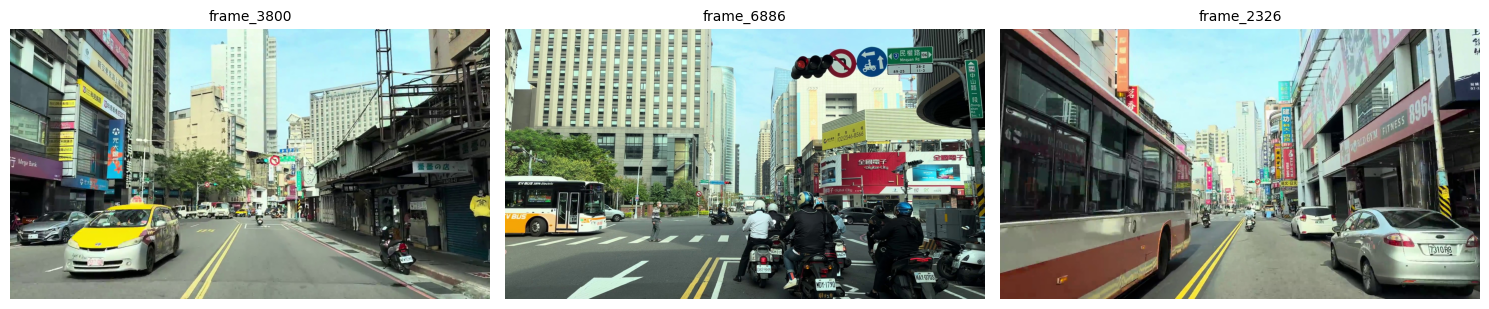


✅ Showing 3 of 3 images in database


In [16]:
# Load images from directory
print("\nLoading images from disk...")
image_paths = list(Path(IMAGE_DIR).glob("*.jpg"))[:50]  # Limit to 50 for demo

if not image_paths:
    raise ValueError(f"No images found in {IMAGE_DIR}")

print(f" Found {len(image_paths)} images")

# Display sample images from the database
print("\n" + "="*60)
print("SAMPLE IMAGES IN DATABASE")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    if i < len(image_paths):
        img = Image.open(image_paths[i])
        ax.imshow(img)
        ax.set_title(f"{image_paths[i].stem}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Showing 3 of {len(image_paths)} images in database")

In [17]:
# Prepare image metadata
# Each image gets:
# - image_id: filename stem (e.g., "frame_001")
# - path: full file path
# - UUID: unique identifier for Qdrant

uris = [str(p) for p in image_paths]
image_metadata_list = [
    {"image_id": p.stem, "path": str(p)} 
    for p in image_paths
]
image_ids = [str(uuid4()) for _ in uris]

print(f" Prepared metadata for {len(image_ids)} images")
print(f"   Example metadata: {image_metadata_list[0]}")

 Prepared metadata for 3 images
   Example metadata: {'image_id': 'frame_3800', 'path': 'RAG_test/frame_3800.jpg'}


In [18]:
# Index images with CLIP embeddings
print("\n" + "="*60)
print("Indexing images with CLIP embeddings...")
print("(This generates 1024-dim vectors for each image)")
print("="*60)

image_db.add_images(
    uris, 
    image_metadata_list, 
    ids=image_ids
)

print(f"\n Successfully indexed {len(image_ids)} images")
print(f"   Vector dimension: 1024")
print(f"   Distance metric: Cosine similarity")


Indexing images with CLIP embeddings...
(This generates 1024-dim vectors for each image)

 Successfully indexed 3 images
   Vector dimension: 1024
   Distance metric: Cosine similarity


---

## Section 11: Generate Scene Descriptions

**Caption generation with Qwen2-VL:**
- Input: Driving scene image
- Output: Natural language description
- Purpose: Enable text-based search over visual content

**Example:**
```
Image: 00001.jpg
Caption: "A yellow taxi drives through an intersection with pedestrians 
          crossing in a crosswalk, traffic lights showing green."
```

In [19]:
# Generate scene descriptions for all images
print("\n" + "="*60)
print("Generating scene descriptions with Qwen2-VL...")
print("(This may take 1-2 minutes for 50 images)")
print("="*60 + "\n")

scene_descriptions = {}

for i, img_path in enumerate(image_paths, 1):
    # Generate caption
    caption = vlm.caption_image(str(img_path))
    scene_descriptions[img_path.stem] = caption
    
    # Print progress
    print(f"[{i}/{len(image_paths)}] {img_path.stem}:")
    print(f"     {caption}\n")

print("\n Generated descriptions for all images")
print(f"   Total captions: {len(scene_descriptions)}")


Generating scene descriptions with Qwen2-VL...
(This may take 1-2 minutes for 50 images)

[1/3] frame_3800:
     The image depicts a bustling urban street with a yellow taxi, several cars, a motorcycle, and various storefronts and signs, including a Mega Bank and a sign for a dental clinic.

[2/3] frame_6886:
     The image depicts a busy urban intersection with a variety of vehicles, including motorcycles, a bus, and cars, waiting at a red traffic light.

[3/3] frame_2326:
     The image depicts a busy urban street with a red bus, several cars, and various storefronts and signs, including one for "WORLD GYM."


 Generated descriptions for all images
   Total captions: 3


---

## Section 12: Demo - Multimodal Retrieval

**Test the retrieval system:**
- Query: "yellow taxi"
- Search both image embeddings (visual) and text descriptions (semantic)
- Return top matching images with confidence scores

In [20]:
print("\n" + "="*60)
print("DEMO: MULTIMODAL RETRIEVAL")
print("="*60)
print(f"Query: '{input_query}'")
print("="*60 + "\n")

# Retrieve top matching image
image_name, top_doc = Retrieve_top_results(
    text_db,
    image_db,
    input_query,
    n_texts=1,      # Consider 1 text result
    n_images=1,     # Consider top 3 image results
    show_contents=True,
    retrieval_path=RETRIEVAL_PATH,
)

print("\n" + "="*60)
print(f"TOP MATCH: {image_name}")
print("="*60)


DEMO: MULTIMODAL RETRIEVAL
Query: 'yellow taxi'

Querying database...
	Retrieving 1 text docs and 1 image docs

Image retrieval scores:
  1. frame_3800: 0.2184

IMAGE RETRIEVAL:
  Metadata: {'image_id': 'frame_3800', 'path': 'RAG_test/frame_3800.jpg'}
  Saved to: RAG_test/retrieved/frame_3800_retrieved.jpeg

 Retrieved results!

Aggregated hit counts: {'frame_3800': 1}

Top match: {'image_id': 'frame_3800'}

TOP MATCH: frame_3800


---

## Section 13: Demo - RAG Chatbot

**Retrieval-Augmented Generation in action:**
1. User asks: "What vehicles are in the image with the yellow taxi?"
2. System retrieves most relevant image
3. Gets scene description for that image
4. Qwen2-VL generates answer grounded in visual context

**Key advantage:** Answers are factual (based on retrieved images), not hallucinated.


DEMO: RAG CHATBOT

User Question: What vehicles are in the image with the yellow taxi?

Querying database...
	Retrieving 1 text docs and 1 image docs

Image retrieval scores:
  1. frame_3800: 0.2138

 Retrieved results!

Aggregated hit counts: {'frame_3800': 1}

Top match: {'image_id': 'frame_3800'}


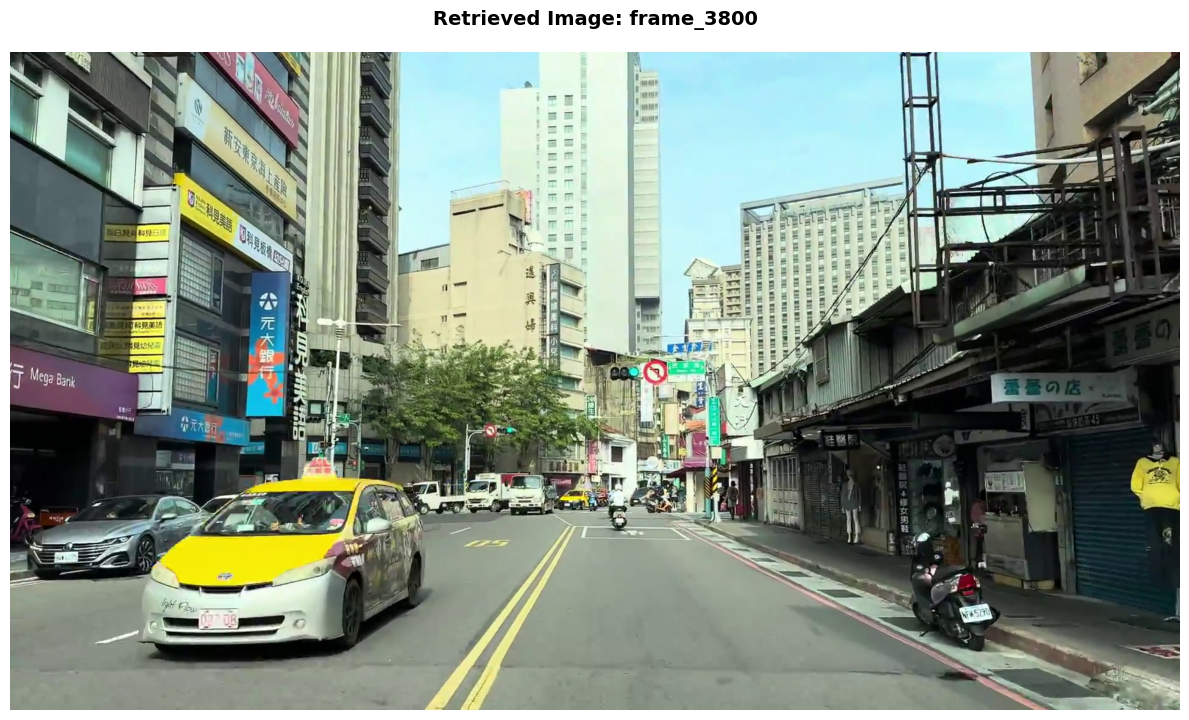


📸 Image: frame_3800
📝 Scene Description: The image depicts a bustling urban street with a yellow taxi, several cars, a motorcycle, and various storefronts and signs, including a Mega Bank and a sign for a dental clinic.

GENERATING RAG RESPONSE...
Querying database...
	Retrieving 1 text docs and 1 image docs

Image retrieval scores:
  1. frame_3800: 0.2138

 Retrieved results!

Aggregated hit counts: {'frame_3800': 1}

Top match: {'image_id': 'frame_3800'}

CONVERSATION:

ASSISTANT: How may I assist you today?

USER: What vehicles are in the image with the yellow taxi?

ASSISTANT: Most relevant image: **frame_3800**

In the image with the yellow taxi, there are several cars and a motorcycle.

 RAG COMPLETE


In [21]:
print("\n" + "="*60)
print("DEMO: RAG CHATBOT")
print("="*60)

# User question
user_question = "What vehicles are in the image with the yellow taxi?"

print(f"\nUser Question: {user_question}\n")
print("="*60)

# First retrieve the image to display it
retrieved_image_name, _ = Retrieve_top_results(
    text_db,
    image_db,
    user_question,
    n_texts=1,
    n_images=1,
    show_contents=False,  # Don't print, we'll display visually
    retrieval_path=None,   # Don't save yet
)

# Display the retrieved image
if retrieved_image_name:
    # Find the image path
    image_path = next(
        (p for p in image_paths if p.stem == retrieved_image_name), 
        None
    )
    
    if image_path:
        # Display image
        img = Image.open(image_path)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f'Retrieved Image: {retrieved_image_name}',
            fontsize=14,
            fontweight='bold',
            pad=20
        )
        plt.tight_layout()
        plt.show()
        
        print(f"\n📸 Image: {retrieved_image_name}")
        print(f"📝 Scene Description: {scene_descriptions.get(retrieved_image_name, 'N/A')}")

# Generate answer using RAG
print("\n" + "="*60)
print("GENERATING RAG RESPONSE...")
print("="*60)

response = simple_chatbot(
    vlm, 
    text_db, 
    image_db, 
    user_question, 
    scene_descriptions,
    retrieval_path=RETRIEVAL_PATH,
)

print("\n" + "="*60)
print(" RAG COMPLETE")
print("="*60)

---

## Summary

### What I presented in this tutorial

1. **Multimodal Embedding System**
   - CLIP ViT-g-14 for image embeddings (1024-dim)
   - Nomic-embed for text embeddings (768-dim)
   - Unified vector space for cross-modal search

2. **Scene Captioning Pipeline**
   - Qwen2-VL-7B generates natural language descriptions
   - Enables semantic search over visual data

3. **RAG Chatbot**
   - Retrieves relevant images for user queries
   - Generates factual answers grounded in visual context
   - Reduces hallucinations

### Production Deployment

To scale this to more than 100K frames, i.e., longer videos:

```python
# 1. Use persistent Qdrant storage
client = QdrantClient(path="./qdrant_data")

# 2. Batch process images
for batch in chunked(image_paths, batch_size=1000):
    image_db.add_images(batch, ...)

# 3. Use quantization for inference
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    load_in_8bit=True,  # 8-bit quantization
)
```

### Applications

This system enables:
- **Dataset exploration** - "Find all scenes with construction zones"
- **Anomaly detection** - Retrieve rare/unusual driving scenarios
- **Annotation assistance** - Auto-label images for training data
- **Failure analysis** - Query specific edge cases for model debugging

---

**Contact:** Victor  
**Project Repository:** [\[Link to GitHub\]](https://github.com/Victor-QTP/materials)
